# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Cody Chhea 

**Date:** 9/2/2026

<StringArray>
[  '145',    '37',    '28',   '199',   '549',   '149',   '250',    '90',
   '270',   '290',
 ...
 '3,100', '2,486', '3,390', '1,356', '2,599',   '472',   '454',   '328',
   '396',   '291']
Length: 511, dtype: str 

Price
150    1481
100    1207
200    1059
125     889
75      873
       ... 
472       1
454       1
328       1
396       1
291       1
Name: count, Length: 511, dtype: int64 

amount missing:  181
After coercion:
 count    30297.000000
mean       153.357032
std        108.895698
min         10.000000
25%         80.000000
50%        125.000000
75%        192.000000
max        999.000000
Name: Price, dtype: float64 

Total missings:
 181 

Median used: 
 125.0
missing after:  0
     Price  Price_impute
101    NaN         125.0
263    NaN         125.0
764    NaN         125.0


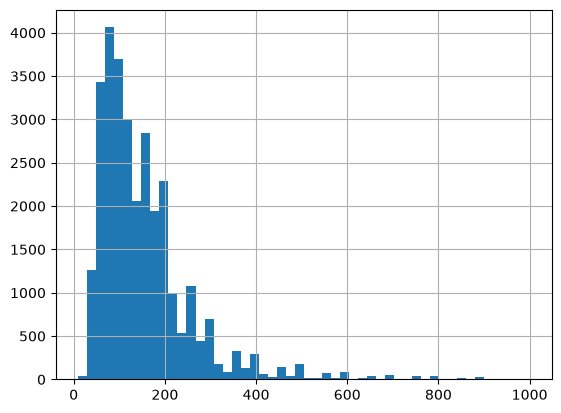

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#cleaning airbnb data 
df = pd.read_csv('airbnb_hw.csv')
df.head()

#we find out that the datatype = string due to the usage of comas, it is not usable numerical data, which is visualized in the inaccurate histogram
var = 'Price'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')


#we converting the dtype to int, allowing to use the numerical data
#we are removing commas or other hidden symbols, converting the price values into ints
df[var] = pd.to_numeric(df[var], errors='coerce')
amount_nan = df[var].isna().sum()
print("amount missing: ", amount_nan)

#creates a new column 'Price_nan' that marks True or False if there is a missing Price in the row 
df['Price_nan'] = df[var].isnull()

#visualize the cleaned data set in a histogram
print('After coercion:\n', df[var].describe(), '\n')
df[var].hist(bins=50)
print('Total missings:\n', sum(df['Price_nan']), '\n')

#we are imputing the NaN values with the median Price
impute_val = df[var].median()
df['Price_impute'] = df[var].fillna(impute_val)
print('Median used: \n', impute_val)
print('missing after: ', df['Price_impute'].isnull().sum())
print(df.loc[df['Price_nan'], [var, 'Price_impute']].head(3))









In [14]:
df1 = pd.read_csv('mn_police_use_of_force.csv')
var = 'subject_injury'

df1[var].describe()
print(df1[var].unique(), '\n')
df1[var] = df1[var].replace(' ', np.nan)
print(df1[var].value_counts(), '\n')

amount_nan = df1[var].isna().sum()
print("amount missing: ", amount_nan)
print(f"proportion of nans in this column: {amount_nan / len(df1[var])}")
# This is a big concern as more than 70% of the data on subject_injury is missing, which is concerning seeing how there was an obvious force put on the subject (indicated by 'force_type'). Missing data putting this could entertain ethical issues as police are not being transparent with their data/actions. In a statistical sense, there is too much data missing for this to be a good dataset to make any generalizations. 
pd.crosstab(df1[var], df1['force_type'],  dropna=False)

#Bodily Force, Chemical Irritant, Less Lethal, Maximal Restraint Technique, Taser --> easier to hide, missing alot. On the other hand, K9 bites or gun point display has a higher percentage of Yes/No rather than missing data, which makes sense as injuries/those incidents are less easy to hide. A K9 bite has obvious marks, which makes it hard for officers to hide data. 






<StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

amount missing:  9848
proportion of nans in this column: 0.7619342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


# Answers for Q1
Q1.1) There are 9848 missing values. I cleaned this dataset by removing the comas from the numerical values (e.g. 1.532). Because there were comas in the entries, the values were strings, and weren't represented as numerical values (I found out by looking at the dtybe and by visualzing as a histogram).

Q1.2) The proportion of missing values in the subject_injury column was 76%. This is a big concern as more than 70% of the data on subject_injury is missing, which is concerning seeing how there was an obvious force put on the subject (indicated by 'force_type'). Missing data putting this could entertain ethical issues as police are not being transparent with their data/actions. In a statistical sense, there is too much data missing for this to be a good dataset to make any generalizations. Bodily Force, Chemical Irritant, Less Lethal, Maximal Restraint Technique, and Taser incidents are easier to hide, which explains why there are so many missing 'subject_injury' values for those types of forces. On the other hand, K9 bites or gun point display has a higher percentage of Yes/No rather than missing data, which makes sense as those injuries/incidents are conspicuous. A K9 bite has obvious marks, which makes it hard for officers to hide data. 



Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')
[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914

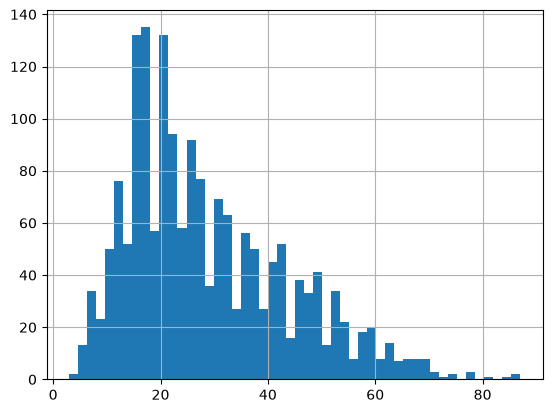

In [10]:


df2 = pd.read_excel('GSAF5.xls')

#Looked at names of all columns 
print(df2.columns)
print(df2['Year'].unique())

#Dropped Unnamed:21 and Unnamed: 22 columns as they have no data
df2_dropped = df2.drop(columns=["Unnamed: 21", "Unnamed: 22"])
print(df2_dropped.columns)

#Clean and filter year to focus on attacks since 1940 
df2_dropped = df2_dropped.dropna(subset=['Year'])
df2_dropped = df2_dropped[df2_dropped['Year'] >= 1940]
df2_dropped['Year'].value_counts()

#age variable has missing, question mark, and notations with plus signs. Coerced these into nan. 
df2_dropped['Age'] = df2_dropped['Age'].replace('?', np.nan)
df2_dropped['Age'] = df2_dropped['Age'].str.replace('+', '', regex=False)
df2_dropped['Age'] = df2_dropped['Age'].replace('!', np.nan)

df2_dropped['Age'] = pd.to_numeric(df2_dropped['Age'], errors='coerce')


#visualize the age variable 
df2_dropped['Age'].hist(bins=50)
#getting male proportion
maleprop = (df2_dropped['Sex'] == 'M').sum() / len(df2_dropped)
print("the male proportion is: ", maleprop)

#Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown.
type_lower = df2_dropped['Type'].str.strip().str.lower()
df2_dropped.loc[type_lower == 'provoked', 'Type'] = 'Provoked'
df2_dropped.loc[type_lower == 'unprovoked', 'Type'] = 'Unprovoked'

#Cleaning the variable so that Unknown is  defined as when there is a missing value, NAN, or ?. 
df2_dropped.loc[type_lower == '?', 'Type'] = 'Unknown'
df2_dropped.loc[type_lower == ' ', 'Type'] = 'Unknown'
df2_dropped.loc[type_lower == 'nan', 'Type'] = 'Unknown'
df2_dropped = df2_dropped[df2_dropped['Type'].isin(['Provoked', 'Unprovoked', 'Unknown'])]
print(df2_dropped['Type'].value_counts())


#Calculating proportion of Unprovoked Attacks
unprovokedprop = (df2_dropped['Type'] == 'Unprovoked').sum() / len(df2_dropped)
print("The proportion of unprovoked attacks is: ",  unprovokedprop)






# Answers to Question 2

- The range of the year variable is 1738-2026. After filtering for years since 1940, we see that attacks seem to be increasing as years go on. 
- The proportion of victims that are male are 0.785522307830138
- The proportion of unprovoked attacks, given that 'Unknown' is defined as having a missing value, '?', or nan, is 0.8872549019607843.



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 178d869ba22a6fdeb9f68fd2f77239983defe90d
- **AI tool and model used:** Gemini Flash-Lite and Claude Sonnet 5 

### *Prompts used

1. Gave 'airbnb_hw.csv' dataset and asked "Did I do a good job cleaning the Price data"? What else could you do?"
2. Gave 'mn_police_use_of_force.csv' dataset and the question. Asked "Check my answers, is my subject_injury correctly cleaned. Is my interpretration regarding the data correct. Did I cross tabulate correctly?"

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

# 1. 
1. How many missing values do you end up with?
Run this above to get the real number:

python
print(df[var].isna().sum())

It will be much smaller than what your buggy version reported, since 181 of those "missing" values were actually just comma-formatted prices.

2. Did you do a good job cleaning it? What else could you do?

Your overall structure is good — you're on the right track with the workflow:

✅ Converting to numeric type
✅ Creating a missingness indicator column (Price_nan) before imputing — this is genuinely good practice, since it preserves information about which rows were imputed
✅ Imputing with the median rather than mean (robust to outliers/skew, which price data usually has)
❌ But the comma bug above means your "before" and "after" pictures were both wrong — the histogram, .describe(), and missing count were all built on corrupted data
# 2. 

1. subject_injury cleaning — mostly fine, one dead line
python
df1[var] = df1[var].replace(' ', np.nan)

This does nothing. I checked — there are zero literal ' ' (space) strings in this column; the only values present are 'Yes', 'No', and actual NaN. So this line is harmless but not doing any real work. It's not wrong to include defensively, but don't credit it in your write-up as "the cleaning step" — the column arrives already only containing Yes/No/NaN, so there's nothing to standardize.

One thing you didn't do that's worth deciding explicitly: you left NaN as NaN rather than recoding it to something like 'Missing'. That's actually the right call — don't fold missing into 'No' — just flag in your write-up that you made that choice deliberately (assuming NaN = "not recorded," not "no injury").

2. Proportion missing — correct, and good interpretation

Your calculation is right: ~76% missing. Your interpretation is strong too — flagging both the statistical problem (too sparse to generalize) and the substantive one (possible inconsistency/selective reporting by officers) shows good instincts. That's exactly the kind of reasoning this question is looking for.

3. Crosstab — works, but only by a technicality you should know about
python
pd.crosstab(df1[var], df1['force_type'], dropna=False)

This does show NaN as its own row — I verified it above, the output index is ['No', 'Yes', nan]. But here's the catch: that's not actually what dropna=False is doing. In pd.crosstab, the dropna parameter controls something else entirely — whether to drop columns that are entirely zero, not whether to include NaN rows/categories. The NaN row shows up here for a different reason: force_type itself has no missing values, so there's nothing to interact badly with.

Try it with dropna=True (the default) instead, and you'd get the exact same table — the NaN row would still appear, because pandas' crosstab/groupby machinery treats NaN specially depending on version and doesn't automatically exclude it here. The point is: your dropna=False isn't the reason the NaN row is showing up, so don't cite it as "I told crosstab to keep the missing values" in your write-up — that's not quite an accurate description of the mechanism. It happened to work, but for a different reason than you think.

Bottom line: your crosstab table is numerically correct (I reproduced it above and it matches), your missingness % is correct, and your interpretation of the pattern (K9 bites/gunpoint have less missingness because injury is harder to hide; Bodily Force/Chemical Irritant have more because it's easier to skip) is well-reasoned and matches what the data actually shows. Just tighten the write-up so you're not attributing the NaN row appearing to dropna=False — say instead that you inspected the table directly and confirmed NaN counts appear per force_type.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  |  The AI is correct in saying that the missing values were calculated incorrectly. I will use the code to correctly calculate the missing values to not incorporate entries with commas|
| 2 | Accept / modify / reject | I rejected the change as when I followed its suggestions to use dropna=True (default) it doesn't show the amount of Na's in the crosstab|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]